In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('./assets/retail.csv', parse_dates=['date'])
df.head()

,id,date,store_nbr,family,sales,onpromotion
0,1945944,2016-01-01,1,AUTOMOTIVE,0.0,0
1,1945945,2016-01-01,1,BABY CARE,0.0,0
2,1945946,2016-01-01,1,BEAUTY,0.0,0
3,1945947,2016-01-01,1,BEVERAGES,0.0,0
4,1945948,2016-01-01,1,BOOKS,0.0,0


In [3]:
sales_df = df.groupby(['date', 'family'], as_index=False).agg(sales=('sales', 'sum'))
sales_df = sales_df.pivot(index='date', columns='family', values='sales')
sales_df.head()

family,AUTOMOTIVE,BABY CARE,BEAUTY,BEVERAGES,BOOKS,BREAD/BAKERY,CELEBRATION,CLEANING,DAIRY,DELI,...,MAGAZINES,MEATS,PERSONAL CARE,PET SUPPLIES,PLAYERS AND ELECTRONICS,POULTRY,PREPARED FOODS,PRODUCE,SCHOOL AND OFFICE SUPPLIES,SEAFOOD
date,,,,,,,,,,,,,,,,,,,,,
2016-01-01,4.0,0.0,13.0,5104.0,0.0,680.95200,13.0,734.0,1033.0,295.181,...,16.0,397.749000,226.0,2.0,10.0,261.179000,94.699000,2384.5090,0.0,13.000000
2016-01-02,625.0,9.0,382.0,250510.0,0.0,33464.57402,1040.0,93377.0,55039.0,22591.372,...,359.0,22850.042968,29527.0,419.0,749.0,25309.535876,7329.263020,146126.1640,145.0,1481.998000
2016-01-03,661.0,17.0,424.0,299177.0,0.0,40905.38003,732.0,103544.0,68371.0,25365.567,...,282.0,24417.722000,33843.0,465.0,863.0,26105.507950,7224.984024,183392.0229,223.0,1819.102997
2016-01-04,407.0,18.0,296.0,217525.0,0.0,31278.86797,575.0,83979.0,52242.0,18488.887,...,128.0,19750.153001,25288.0,287.0,527.0,19478.054057,5783.658974,155059.5071,114.0,1392.717995
2016-01-05,338.0,4.0,279.0,187069.0,0.0,27189.87697,616.0,72688.0,45174.0,16308.949,...,134.0,18885.021020,20842.0,303.0,398.0,20233.733990,5435.500005,141014.1231,118.0,1200.327004


<Axes: title={'center': 'Jan Dairy sales'}, xlabel='date', ylabel='sales'>

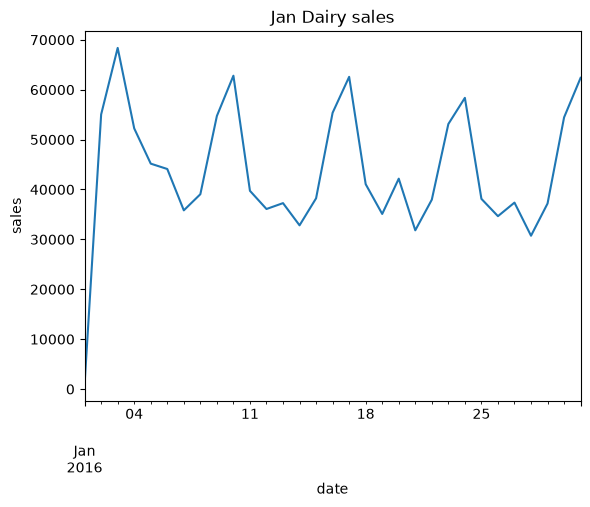

In [4]:
sales_df.loc['2016-01', 'DAIRY'].plot(
    title='Jan Dairy sales',
    xlabel='date',
    ylabel='sales'
)

In [5]:
transactions = pd.read_csv('./assets/transactions.csv', parse_dates=['date'])
transactions_44 = transactions.query("store_nbr == 44").drop("store_nbr", axis=1).reset_index(drop=True)
transactions_44.head()

,date,transactions
0,2013-01-02,4821
1,2013-01-03,3618
2,2013-01-04,4169
3,2013-01-05,4921
4,2013-01-06,4925


<Axes: title={'center': 'store 44 transactions 2013-2017'}, xlabel='year', ylabel='daily transactions'>

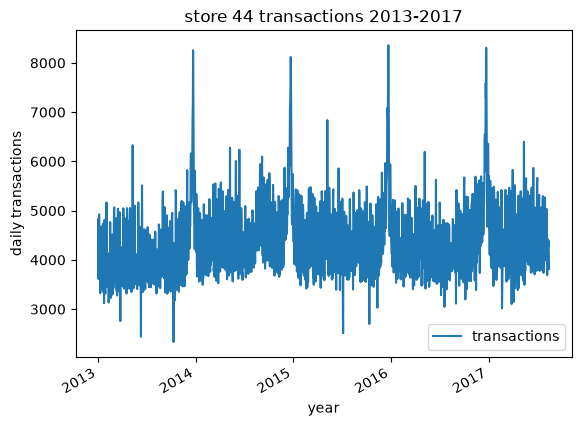

In [6]:
transactions_44.plot(
    x='date',
    title='store 44 transactions 2013-2017',
    xlabel='year',
    ylabel='daily transactions'
)

<Axes: xlabel='date'>

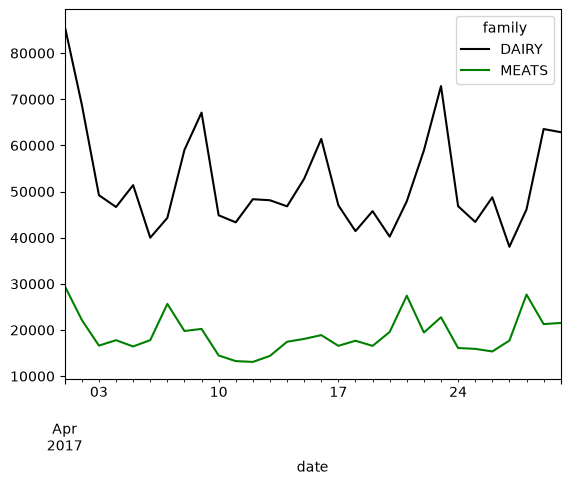

In [17]:
sales_df.loc['2017-4', ['DAIRY', 'MEATS']].plot(
    color=['#000', 'green']
)

<Axes: xlabel='date'>

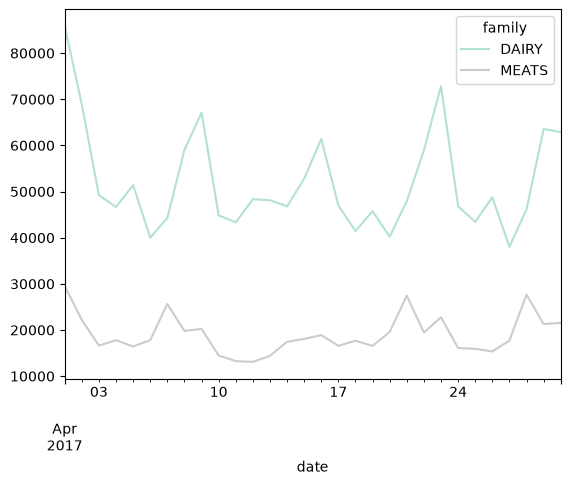

In [20]:
sales_df.loc['2017-4', ['DAIRY', 'MEATS']].plot(
    cmap="Pastel2"
)

<Axes: title={'center': 'store 44 transactions 2013-2017'}, xlabel='year', ylabel='daily transactions'>

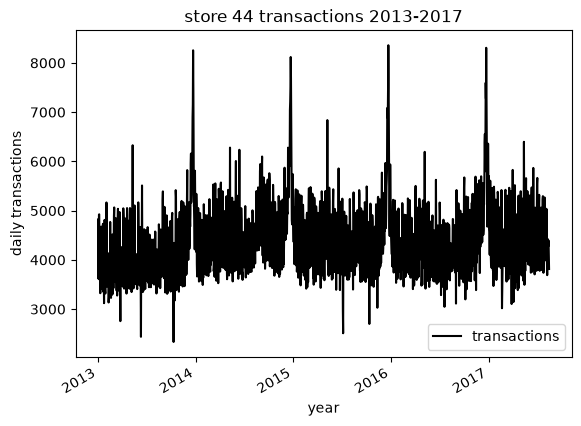

In [24]:
transactions_44.plot(
    x='date',
    title='store 44 transactions 2013-2017',
    xlabel='year',
    ylabel='daily transactions',
    c='k'
)

<Axes: xlabel='date'>

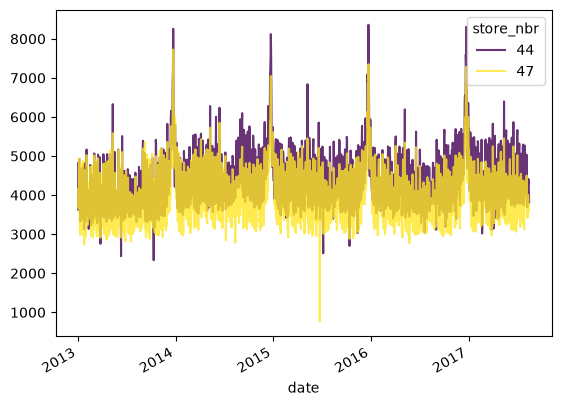

In [35]:
(transactions.query("store_nbr in [44, 47]")
     .pivot(index='date', columns='store_nbr', values='transactions')
     .plot(
         cmap= 'viridis',
         alpha= .8
     )
)

<Axes: xlabel='date'>

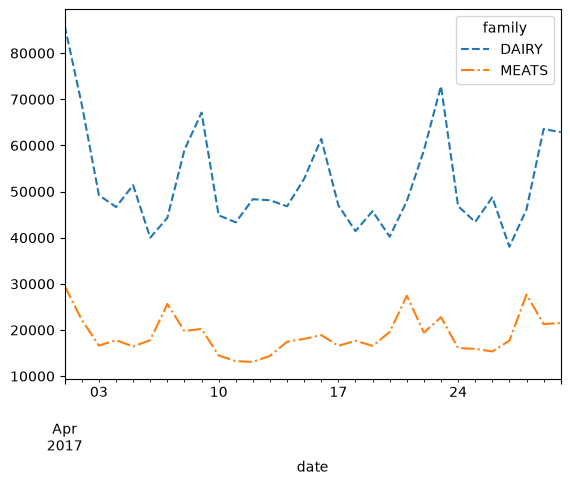

In [38]:
sales_df.loc['2017-4', ['DAIRY', 'MEATS']].plot(
    style=['--', '-.']
)

<Axes: xlabel='date'>

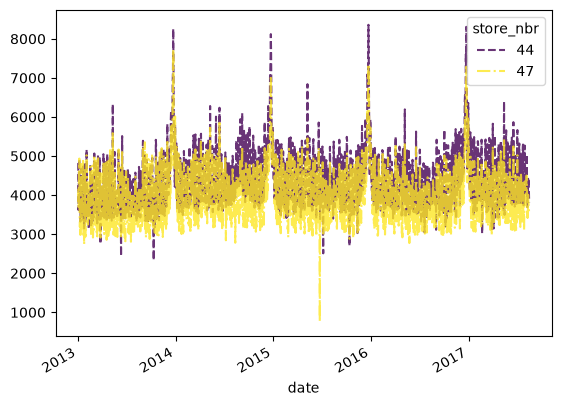

In [41]:
(transactions.query("store_nbr in [44, 47]")
     .pivot(index='date', columns='store_nbr', values='transactions')
     .plot(
         cmap= 'viridis',
         alpha= .8,
         style= ['--', '-.']
     )
)

<Axes: xlabel='date'>

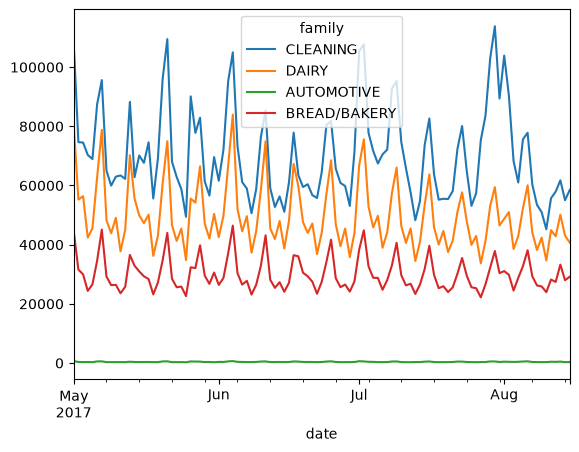

In [48]:
sales_df.loc['2017-5':,['CLEANING','DAIRY','AUTOMOTIVE','BREAD/BAKERY']].plot()

<Axes: xlabel='date'>

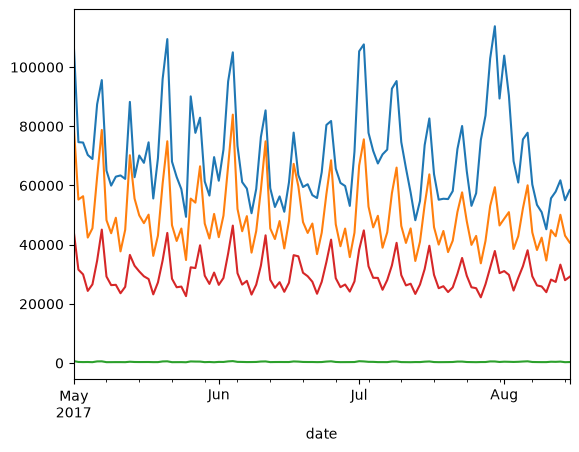

In [49]:
(sales_df
    .loc['2017-5':,['CLEANING','DAIRY','AUTOMOTIVE','BREAD/BAKERY']]
    .plot(
        legend=False
    )
)

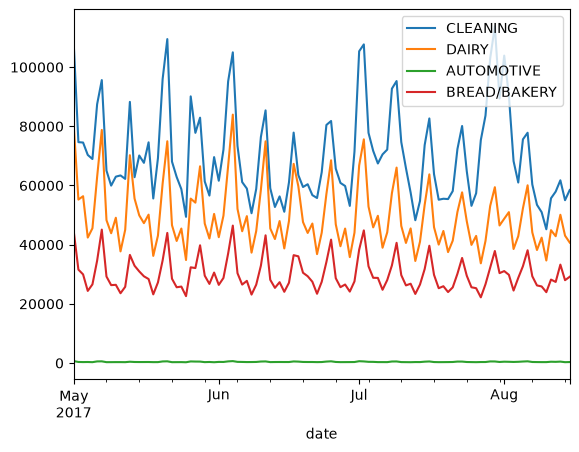

In [52]:
(sales_df
    .loc['2017-5':,['CLEANING','DAIRY','AUTOMOTIVE','BREAD/BAKERY']]
    .plot()
    .legend(loc='upper right')
)

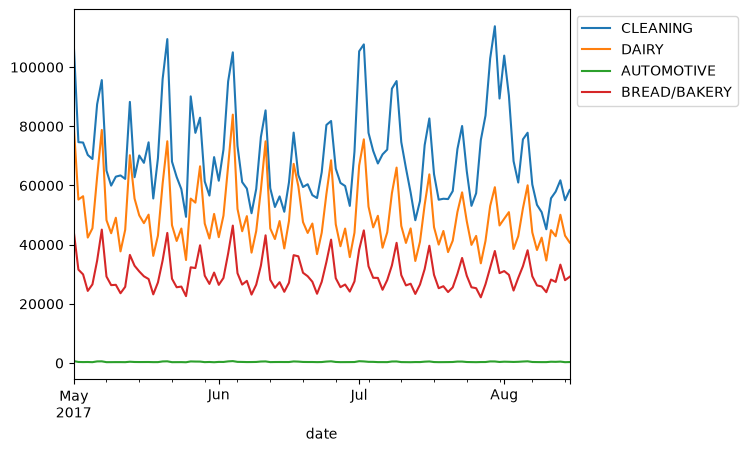

In [54]:
(sales_df
    .loc['2017-5':,['CLEANING','DAIRY','AUTOMOTIVE','BREAD/BAKERY']]
    .plot()
    .legend(bbox_to_anchor=(1, 1))
)

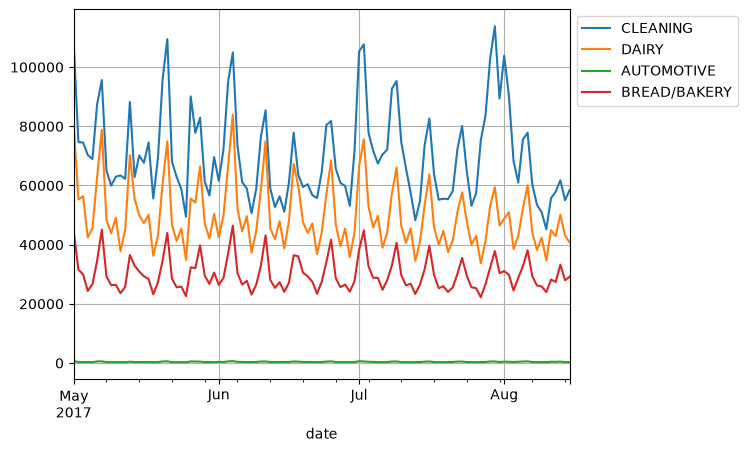

In [55]:
(sales_df
    .loc['2017-5':,['CLEANING','DAIRY','AUTOMOTIVE','BREAD/BAKERY']]
    .plot(grid=True)
    .legend(bbox_to_anchor=(1, 1))
)